In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

In [ ]:
df = pd.read_csv("OnlineRetail.csv", encoding="latin1")   # latin1 fixes the £ sign error
df = df.rename(columns={"InvoiceNo": "Invoice", "UnitPrice": "Price"})  # shorter, matching names

print(df.shape)
print(df.columns.tolist())
df.head()

(541909, 8)
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.info()                         # column types and non-empty counts
print(df.describe())              # min, max, average of number columns
print(df.isnull().sum())          # missing values per column
print(df.duplicated().sum())      # number of duplicate rows

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   Price        541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
            Quantity          Price     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16

In [ ]:
print("Raw rows:", len(df))
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%Y %H:%M')
df = df.drop_duplicates()
print("After duplicates:", len(df))
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)
print("After missing CustomerID:", len(df))
df['Invoice'] = df['Invoice'].astype(str)
df = df[~df['Invoice'].str.startswith('C')]
print("After cancellations:", len(df))
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
print("After bad quantity/price:", len(df))
df['TotalPrice'] = df['Quantity'] * df['Price']
print(df['CustomerID'].nunique(), "customers")
print(df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())

Raw rows: 401604
After duplicates: 401604
After missing CustomerID: 401604
After cancellations: 392732
After bad quantity/price: 392692
4338 customers
2010-12-01 08:26:00 to 2011-12-09 12:50:00


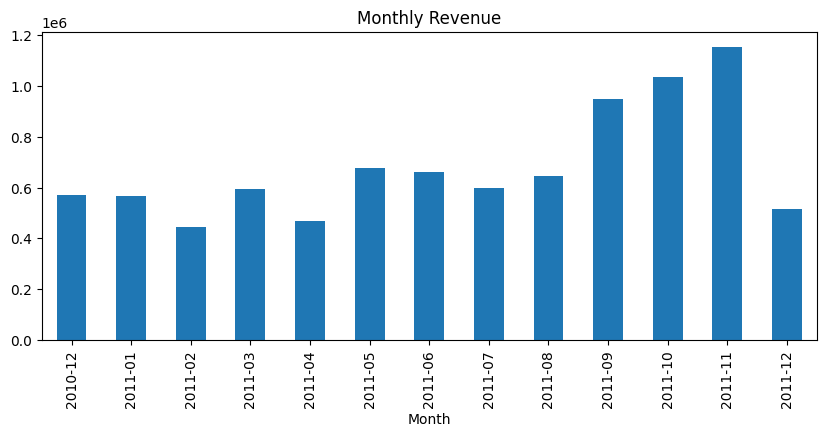

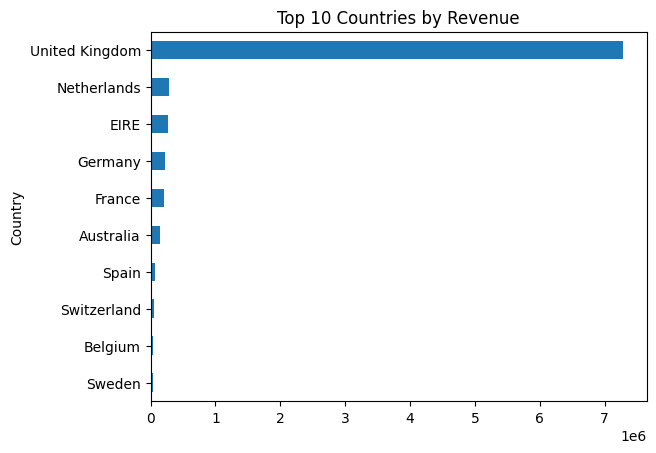

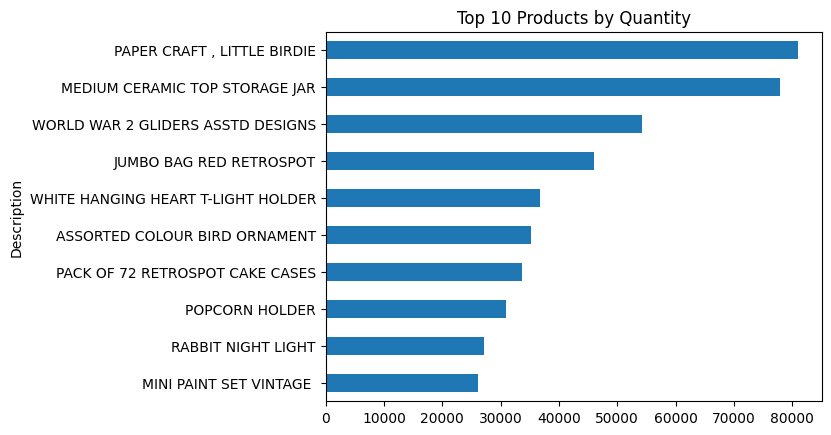

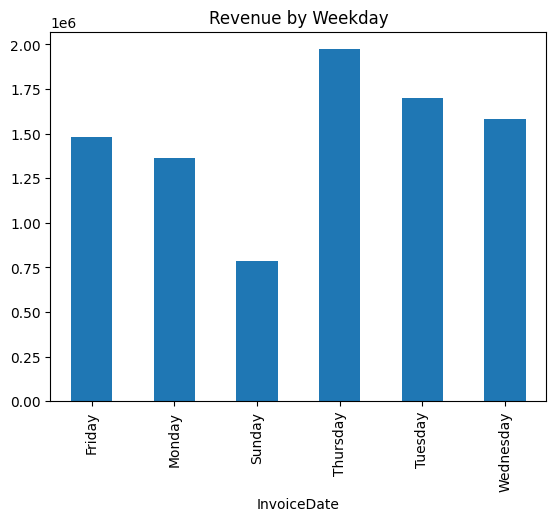

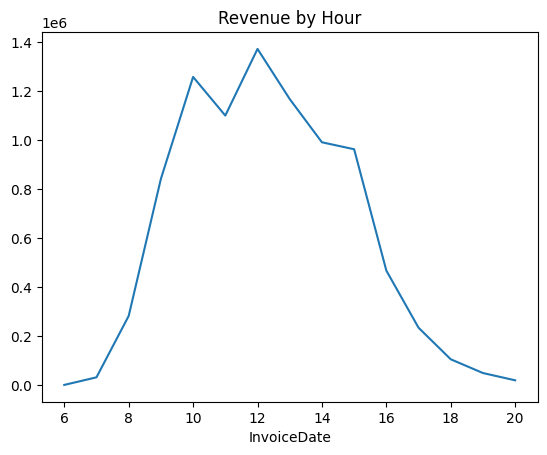

UK share of revenue: 82.0%
Top 20% of customers generate 74.7% of revenue


In [ ]:
total = df['TotalPrice'].sum()
#revenue month
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df.groupby('Month')['TotalPrice'].sum().plot(kind='bar', figsize=(10, 4), title='Monthly Revenue')
plt.show()

#countries revenue top 10
top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
top_countries[::-1].plot(kind='barh', title='Top 10 Countries by Revenue')   # [::-1] flips the order
plt.show()

#top 10 products by untity sold
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top_products[::-1].plot(kind='barh', title='Top 10 Products by Quantity')
plt.show()

# revenue by weekdat and hour
df.groupby(df['InvoiceDate'].dt.day_name())['TotalPrice'].sum().plot(kind='bar', title='Revenue by Weekday')
plt.show()
df.groupby(df['InvoiceDate'].dt.hour)['TotalPrice'].sum().plot(title='Revenue by Hour')
plt.show()

# how much from uk and best cutomer
uk_share = df[df['Country'] == 'United Kingdom']['TotalPrice'].sum() / total * 100
print("UK share of revenue: %.1f%%" % uk_share)

cust = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False)
top20 = cust.head(int(len(cust) * 0.2)).sum() / total * 100
print("Top 20%% of customers generate %.1f%% of revenue" % top20)

In [ ]:
#rfm table
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),  # days since last purchase
    Frequency = ('Invoice', 'nunique'),                                     # number of different invoices
    Monetary  = ('TotalPrice', 'sum')                                       # total money spent
).reset_index()

print(rfm.describe())

         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2048.688081
std     1721.808492   100.014169     7.697998    8985.230220
min    12346.000000     1.000000     1.000000       3.750000
25%    13813.250000    18.000000     1.000000     306.482500
50%    15299.500000    51.000000     2.000000     668.570000
75%    16778.750000   142.000000     5.000000    1660.597500
max    18287.000000   374.000000   209.000000  280206.020000


In [ ]:
rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])
scaler = StandardScaler()
X = scaler.fit_transform(rfm_log)

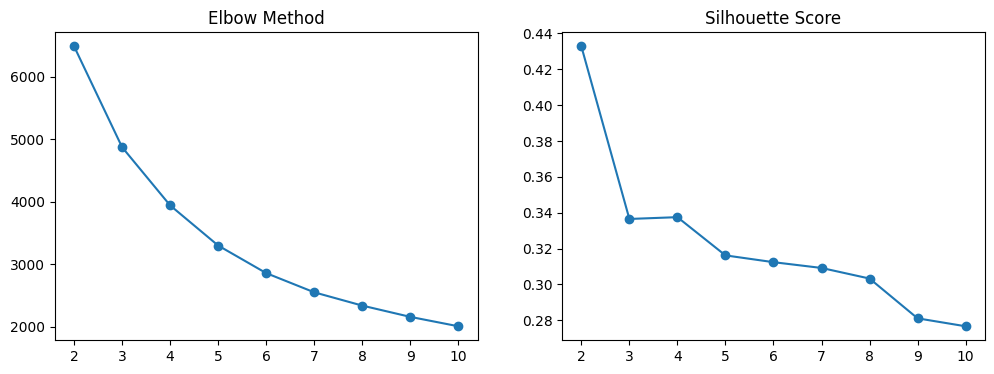

In [ ]:
# ab dhundenge k!!!!!! anurag kashyab reference?!!!!
inertia = []
sil = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, labels))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(K_range, inertia, marker='o'); ax[0].set_title('Elbow Method')
ax[1].plot(K_range, sil, marker='o');     ax[1].set_title('Silhouette Score')
plt.show()

In [ ]:
#Model train karenge
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X)
print("Silhouette score:", round(silhouette_score(X, rfm['Cluster']), 3))

profile = rfm.groupby('Cluster').agg(
    Customers      = ('CustomerID', 'count'),
    Avg_Recency    = ('Recency', 'mean'),
    Avg_Frequency  = ('Frequency', 'mean'),
    Avg_Monetary   = ('Monetary', 'mean'),
    Total_Monetary = ('Monetary', 'sum')
).round(1)

profile['Revenue_share_%'] = (profile['Total_Monetary'] / rfm['Monetary'].sum() * 100).round(1)
profile

Silhouette score: 0.338


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Monetary,Revenue_share_%
Cluster,,,,,,
0,713,12.2,13.8,8088.0,5766757.1,64.9
1,1622,181.5,1.3,341.0,553099.8,6.2
2,837,17.7,2.2,557.3,466479.0,5.2
3,1166,71.6,4.1,1801.8,2100873.0,23.6


         Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Monetary  \
Cluster                                                                        
0              713         12.2           13.8        8088.0       5766757.1   
1             1622        181.5            1.3         341.0        553099.8   
2              837         17.7            2.2         557.3        466479.0   
3             1166         71.6            4.1        1801.8       2100873.0   

         Revenue_share_%                    Segment  
Cluster                                              
0                   64.9                  Champions  
1                    6.2         Lost / Hibernating  
2                    5.2  New / Recent Low-Spenders  
3                   23.6            Loyal Customers  


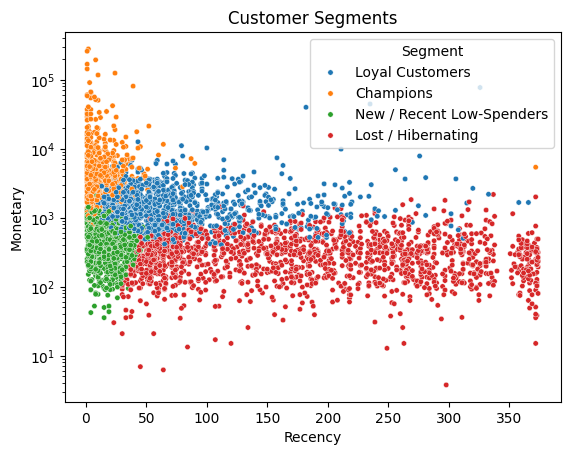

In [ ]:
#cluster ranking
rank = profile['Avg_Monetary'].sort_values(ascending=False).index.tolist()
labels_map = dict(zip(rank, ['Champions', 'Loyal Customers',
                             'New / Recent Low-Spenders', 'Lost / Hibernating']))

rfm['Segment'] = rfm['Cluster'].map(labels_map)
profile['Segment'] = profile.index.map(labels_map)
print(profile)
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Segment', palette='tab10', s=15)
plt.yscale('log')
plt.title('Customer Segments')
plt.show()

In [ ]:
#model save
joblib.dump(kmeans, 'kmeans_model.pkl')     # the trained model
joblib.dump(scaler, 'scaler.pkl')           # the scaler (new customers must be scaled the same way)
rfm.to_csv('customer_segments.csv', index=False)

In [ ]:
#testing the model
model = joblib.load('kmeans_model.pkl')
sc = joblib.load('scaler.pkl')

# A new customer: bought 10 days ago, 8 orders, spent £2,500
new = pd.DataFrame(np.log1p([[10, 8, 2500]]), columns=['Recency', 'Frequency', 'Monetary'])
new_scaled = sc.transform(new)
print("This customer belongs to:", labels_map[model.predict(new_scaled)[0]])

This customer belongs to: Champions
